#Transformer

## 0. Config and Imports

In [1]:
import os
from pathlib import Path
import json
import pandas as pd
import random
import math
import copy
import numpy as np
import matplotlib.pyplot as plt
import pprint as pp

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from torch.optim.lr_scheduler import StepLR, ReduceLROnPlateau

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"CUDA Available: {torch.cuda.is_available()}")

CUDA Available: True


In [3]:
# Fixing seed to remove randomness, for better comparisons
seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.use_deterministic_algorithms(True)

### A. Local Setup

In [4]:
DATA_DIR = Path('./data')# Path to dataset
DATA_DIR.mkdir(parents=True,exist_ok=True)

MODEL_DIR = Path("./model")
MODEL_DIR.mkdir(parents=True,exist_ok=True)

### B. Colab Setup

In [5]:
# !pip -q install gdown

# DATA_DIR = Path("/content/ML_Exam_Project/data")
# DATA_DIR.mkdir(parents=True,exist_ok=True)

# MODEL_DIR = Path("/content/ML_Exam_Project/model")
# MODEL_DIR.mkdir(parents=True,exist_ok=True)

# DATA_FOLDER_URL = "https://drive.google.com/drive/folders/17Cklb8rQ2DJt_NoWPCbgqkd16V1MOXiw?usp=sharing"
# MODEL_FOLDER_URL = "https://drive.google.com/drive/folders/1D2treqldEpK5vJJd2twgP2_QmNY6PE1n?usp=sharing"

# !gdown --folder "$DATA_FOLDER_URL" -O "$DATA_DIR"
# !gdown --folder "$MODEL_FOLDER_URL" -O "$MODEL_DIR"

## 1. Data Loading

### 1.1 File Sanity Check

In [6]:
expected_files = [
    "train.jsonl",
    "validation.jsonl",
    "test_id.jsonl",
    "test_ood.jsonl",
    "test_long.jsonl",
    "train_augmented_A.jsonl",
    "train_augmented_B.jsonl",
    "train_augmented_C.jsonl",
    "validation_augmented_A.jsonl",
    "validation_augmented_B.jsonl",
    "validation_augmented_C.jsonl"
]

for filename in expected_files:
    path = DATA_DIR / filename
    assert path.exists(), f"Missing file: {path}"

print("All dataset files found:")
for filename in expected_files:
    print(" -", DATA_DIR / filename)

All dataset files found:
 - data\train.jsonl
 - data\validation.jsonl
 - data\test_id.jsonl
 - data\test_ood.jsonl
 - data\test_long.jsonl
 - data\train_augmented_A.jsonl
 - data\train_augmented_B.jsonl
 - data\train_augmented_C.jsonl
 - data\validation_augmented_A.jsonl
 - data\validation_augmented_B.jsonl
 - data\validation_augmented_C.jsonl


### 1.2 Data Loading

In [7]:
# Function to load jsonl into pandas df object
def load_jsonl(path):
    records = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            records.append(json.loads(line))
    return pd.DataFrame(records)

In [8]:
data = {}
for filename in expected_files:
    data[filename.split(".")[0]] = load_jsonl(DATA_DIR / filename)

In [9]:
# Choose what goes into the training and validation (augmented etc.)
combined_train_df = pd.concat([data["train"]], ignore_index=True)
combined_validation_df = pd.concat([data["validation"]], ignore_index=True)

## 2. Data Analysis

### 2.1 Data shapes

In [10]:
print("Train:", data["train"].shape)
print("Train Augmented A:", data["train_augmented_A"].shape)
print("Train Augmented B:", data["train_augmented_B"].shape)
print("Train Augmented C:", data["train_augmented_C"].shape)
print("Validation:", data["validation"].shape)
print("Validation Augmented A:", data["validation_augmented_A"].shape)
print("Validation Augmented B:", data["validation_augmented_B"].shape)
print("Validation Augmented C:", data["validation_augmented_C"].shape)
print("Test ID:", data["test_id"].shape)
print("Test OOD:", data["test_ood"].shape)
print("Test long:", data["test_long"].shape)

Train: (12000, 6)
Train Augmented A: (36000, 6)
Train Augmented B: (12000, 6)
Train Augmented C: (36000, 6)
Validation: (2000, 6)
Validation Augmented A: (6000, 6)
Validation Augmented B: (2000, 6)
Validation Augmented C: (6000, 6)
Test ID: (2000, 6)
Test OOD: (2000, 6)
Test long: (1500, 6)


### 2.2 Data Example

In [11]:
data["train"].head()

,id,expression,value,length,operator_count,depth
0,train-00000,4+4+7+3+8-1,25,11,5,5
1,train-00001,5-(6-5)+8+8,20,11,4,5
2,train-00002,5-3+1,3,5,2,3
3,train-00003,1-(1+5+8+7+1),-21,13,5,6
4,train-00004,7+1-(6+5+9),-12,11,4,4


### 2.3 Test for White Space

It is important to test for white spaces to know if it is required to strip them away because whitespaces such as (1 + 1 3) is a wrong mathematical expression. Furthermore, our plan to use a binary tree to linearize mathematical expression may run into issues if we use whitespace to separate terms

In [12]:
def check_for_whitespace(dataframes):
    if isinstance(dataframes, pd.DataFrame):
        dfs = [dataframes]
    else:
        dfs = dataframes

    for i, df in enumerate(dfs, start=1):
        if not isinstance(df, pd.DataFrame):
            raise TypeError(f"Element {i} is not a DataFrame")

    combined_df = pd.concat(dfs, ignore_index=True)

    return combined_df["expression"].astype(str).str.contains(r"\s").any()

In [13]:
print("White Space Exist") if check_for_whitespace(data.values()) else print("No Whitespace found")

No Whitespace found


### 2.4 Test for Unary Operators

Unary operators like -5 have to be considered when constructing expression trees, if unary operators exist, we have to preprocess our data in a way where the sign and the number are interpreted as one (i.e. "-5" instead of "- 5")

In [14]:
def check_for_unary_operators(dataframes):
    if isinstance(dataframes, pd.DataFrame):
        dfs = [dataframes]
    else:
        dfs = dataframes

    for i, df in enumerate(dfs, start=1):
        if not isinstance(df, pd.DataFrame):
            raise TypeError(f"Element {i} is not a DataFrame")

    combined_df = pd.concat(dfs, ignore_index=True)

    def has_unary(expr):
        expr = str(expr)

        for i, ch in enumerate(expr):
            if ch in "+-":
                if i == 0:
                    return True
                if expr[i - 1] in "(-+":
                    return True
        return False

    return combined_df["expression"].apply(has_unary).any()

In [15]:
print("Unary Operator Exist") if check_for_unary_operators(data.values()) else print("No Unary Operator found")

No Unary Operator found


### 2.5 Tokenization

In [16]:
PAD_TOKEN = "[PAD]"
VOCABULARY = None # Built Dynamically
VOCAB_SIZE = 0

def tokenize(expression_list):
    global VOCABULARY, PAD_TOKEN

    all_chars = set()
    for expression in expression_list:
        for char in expression:
            all_chars.add(char)

    VOCABULARY = sorted(list(all_chars))
    VOCABULARY = [PAD_TOKEN] + VOCABULARY + [" "]
    token_to_index = {token: i for i, token in enumerate(VOCABULARY)}

    return token_to_index

token_to_index = tokenize(data["train"]["expression"].to_list())
print(token_to_index)

VOCAB_SIZE =len(VOCABULARY)

{'[PAD]': 0, '(': 1, ')': 2, '+': 3, '-': 4, '0': 5, '1': 6, '2': 7, '3': 8, '4': 9, '5': 10, '6': 11, '7': 12, '8': 13, '9': 14, ' ': 15}


In [17]:
def encode(expression):
    return [token_to_index[token] for token in list(expression)]

def decode(indices):
    return ''.join([VOCABULARY[index] for index in indices if VOCABULARY[index] != PAD_TOKEN])

# Verify that index encoding is working as intended
print(encode('+'))
print(decode(encode('+')))

[3]
+


### 2.6 Data Preprocessing and Transformation

In this step, we aim to represent our input data in a different form in an attempt to help our models learn better

#### 2.6.1 ExpressionTree, Prefix, Postfix

In [18]:
# Node Structure (Intermediary structure required to build trees)
class Node:
    def __init__(self, value, left=None, right=None):
        self.value = value
        self.left = left
        self.right = right

In [19]:
# ExpressionTree Class (class used to represent mathematical expression)
class ExpressionTree:
    def __init__(self, root_node):
        self.root_node = root_node

    def get_root_node(self):
        return self.root_node

    def to_postfix(self):
        def dfs(node):
            if node is None:
                return []
            return dfs(node.left) + dfs(node.right) + [str(node.value)]

        return " ".join(dfs(self.root_node))

    def to_prefix(self):
        def dfs(node):
            if node is None:
                return []
            return [str(node.value)] + dfs(node.left) + dfs(node.right)

        return " ".join(dfs(self.root_node))

    def get_depth(self):
        def dfs(node, current_depth):
            if node is None:
                return current_depth - 1

            left_depth = dfs(node.left, current_depth + 1)
            right_depth = dfs(node.right, current_depth + 1)

            return max(left_depth, right_depth)

        if self.root_node is None:
            return 0

        return dfs(self.root_node, 1)

    def get_operator_count(self):
        operators = "+-"

        def dfs(node):
            if node is None:
                return 0

            count = 1 if str(node.value) in operators else 0

            count += dfs(node.left)
            count += dfs(node.right)

            return count

        return dfs(self.root_node)

In [20]:
def reduce(operator_stack, operand_stack):
    op = operator_stack.pop()

    right = operand_stack.pop()
    left = operand_stack.pop()

    operand_stack.append(Node(op, left, right))


def build_tree_with_expression(expression):
    subtree_stack = []
    operator_stack = []

    for ch in expression:

        if ch.isnumeric():
            subtree_stack.append(Node(ch))

        elif ch == '(':
            operator_stack.append(ch)

        elif ch == ')':
            while operator_stack[-1] != '(':
                reduce(operator_stack, subtree_stack)

            operator_stack.pop()  # remove '('

        elif ch in '+-':

            while (
                operator_stack
                and operator_stack[-1] != '('
            ):
                reduce(operator_stack, subtree_stack)

            operator_stack.append(ch)

    while operator_stack:
        reduce(operator_stack, subtree_stack)

    root = subtree_stack.pop()
    return ExpressionTree(root)

expression = "5-(6-5)+8+8"
build_tree_with_expression(expression).to_postfix()

'5 6 5 - - 8 + 8 +'

#### 2.6.2 Target Value Normalization
Normalizing the target variable (output) can help improve model performance and stability during training, especially with regression tasks. By scaling the target values, the model can learn more efficiently. We will normalize `y_train` and `y_val` using the mean and standard deviation calculated from `y_train`.

In [21]:
# Calculate mean and standard deviation from training targets
y_mean = data["train"]["value"].mean()
y_std = data["train"]["value"].std()

print(f"Training target mean: {y_mean:.2f}")
print(f"Training target standard deviation: {y_std:.2f}")

Training target mean: 4.86
Training target standard deviation: 10.59


In [22]:
def normalize_target_value(value,mean,std):
    return (value - mean) / std

def denormalize_target_value(normalized_value, mean, std):
    return normalized_value * std + mean

### 2.7 Applying Transformations

In this step, we apply the previously discussed preprocessing steps

In [23]:
def apply_transformation(df):
    df["normalized_value"] = df["value"].apply(lambda y: normalize_target_value(y, y_mean, y_std))
    df["prefix"] = df["expression"].apply(lambda x: build_tree_with_expression(x).to_prefix())
    df["postfix"] = df["expression"].apply(lambda x: build_tree_with_expression(x).to_postfix())

    return df

In [24]:
for data_split, df in data.items():
    data[data_split] = apply_transformation(df)


data['train'].head()

,id,expression,value,length,operator_count,depth,normalized_value,prefix,postfix
0,train-00000,4+4+7+3+8-1,25,11,5,5,1.901590,- + + + + 4 4 7 3 8 1,4 4 + 7 + 3 + 8 + 1 -
1,train-00001,5-(6-5)+8+8,20,11,4,5,1.429479,+ + - 5 - 6 5 8 8,5 6 5 - - 8 + 8 +
2,train-00002,5-3+1,3,5,2,3,-0.175696,+ - 5 3 1,5 3 - 1 +
3,train-00003,1-(1+5+8+7+1),-21,13,5,6,-2.441825,- 1 + + + + 1 5 8 7 1,1 1 5 + 8 + 7 + 1 + -
4,train-00004,7+1-(6+5+9),-12,11,4,4,-1.592027,- + 7 1 + + 6 5 9,7 1 + 6 5 + 9 + -


### 2.8 Summary of Data

Here, we create a function to give a summary of our data so we can compare the different data splits

In [25]:
# Function to return summary of data
# It is possible to calculate the summary of multiple data split together by passing them in together
def summary(*data_df):
    for i, df in enumerate(data_df, start=1):
        if not isinstance(df, pd.DataFrame):
            raise TypeError(f"Argument {i} is not a DataFrame")

    combined_df = pd.concat(data_df, ignore_index=True)

    result = pd.DataFrame({
        "mean": combined_df.mean(numeric_only=True),
        "std": combined_df.std(numeric_only=True),
        "min": combined_df.min(numeric_only=True),
        "max": combined_df.max(numeric_only=True),

    })

    # Expecting comparison of data split with different size, so we have to normalise for more meaningful comparison
    result.loc["value", "positive_ratio"] = (combined_df["value"] > 0).mean()
    result.loc["value", "negative_ratio"] = (combined_df["value"] < 0).mean()
    result.loc["value", "zero_ratio"] = (combined_df["value"] == 0).mean()

    mode = combined_df.mode(numeric_only=True).iloc[0]
    result["mode"] = mode

    return result

In [26]:
for split_name,df in data.items():
    display(summary(df).style.set_caption(f"{split_name}"))
    print("\n\n\n")

,mean,std,min,max,positive_ratio,negative_ratio,zero_ratio,mode
value,4.860750,10.590745,-36.000000,46.000000,0.657250,0.306167,0.036583,2.000000
length,9.607000,3.184713,5.000000,19.000000,nan,nan,nan,7.000000
operator_count,3.489917,1.116319,2.000000,5.000000,nan,nan,nan,4.000000
depth,3.689917,0.736870,3.000000,6.000000,nan,nan,nan,4.000000
normalized_value,-0.000000,1.000000,-3.858156,3.884453,nan,nan,nan,-0.270118


,mean,std,min,max,positive_ratio,negative_ratio,zero_ratio,mode
value,4.585000,10.718219,-32.000000,47.000000,0.640000,0.323000,0.037000,4.000000
length,9.604000,3.179975,5.000000,19.000000,nan,nan,nan,7.000000
operator_count,3.497000,1.115174,2.000000,5.000000,nan,nan,nan,3.000000
depth,3.679000,0.733640,3.000000,6.000000,nan,nan,nan,3.000000
normalized_value,-0.026037,1.012036,-3.480468,3.978875,nan,nan,nan,-0.081274


,mean,std,min,max,positive_ratio,negative_ratio,zero_ratio,mode
value,5.232500,10.638516,-29.000000,40.000000,0.668000,0.296000,0.036000,8.000000
length,9.609000,3.239192,5.000000,19.000000,nan,nan,nan,7.000000
operator_count,3.487000,1.134669,2.000000,5.000000,nan,nan,nan,2.000000
depth,3.722000,0.780398,3.000000,6.000000,nan,nan,nan,4.000000
normalized_value,0.035101,1.004511,-3.197202,3.317921,nan,nan,nan,0.296414


,mean,std,min,max,positive_ratio,negative_ratio,zero_ratio,mode
value,4.855500,12.016190,-38.000000,44.000000,0.638000,0.332000,0.030000,5.000000
length,12.484000,3.562596,7.000000,23.000000,nan,nan,nan,9.000000
operator_count,4.515500,1.109223,3.000000,6.000000,nan,nan,nan,5.000000
depth,4.434500,1.058428,3.000000,7.000000,nan,nan,nan,4.000000
normalized_value,-0.000496,1.134593,-4.047001,3.695609,nan,nan,nan,0.013148


,mean,std,min,max,positive_ratio,negative_ratio,zero_ratio,mode
value,4.024667,13.545271,-42.000000,51.000000,0.609333,0.362000,0.028667,7.000000
length,17.744000,2.593379,15.000000,27.000000,nan,nan,nan,15.000000
operator_count,6.214667,0.760463,5.000000,7.000000,nan,nan,nan,7.000000
depth,5.500667,1.413034,4.000000,8.000000,nan,nan,nan,4.000000
normalized_value,-0.078945,1.278973,-4.424689,4.356563,nan,nan,nan,0.201992


...

,mean,std,min,max,positive_ratio,negative_ratio,zero_ratio,mode
value,3.349417,12.794275,-45.000000,46.000000,0.596000,0.374750,0.029250,9.000000
length,17.629333,2.912498,11.000000,21.000000,nan,nan,nan,19.000000
operator_count,6.936667,1.474959,3.000000,9.000000,nan,nan,nan,7.000000
depth,6.803750,1.550786,4.000000,10.000000,nan,nan,nan,7.000000
normalized_value,-0.142703,1.208062,-4.707955,3.884453,nan,nan,nan,0.390837


,mean,std,min,max,positive_ratio,negative_ratio,zero_ratio,mode
value,7.535917,13.212616,-45.000000,60.000000,0.700333,0.274389,0.025278,6.000000
length,16.889056,3.731245,11.000000,21.000000,nan,nan,nan,19.000000
operator_count,6.739222,1.743965,3.000000,10.000000,nan,nan,nan,5.000000
depth,6.474306,1.724893,4.000000,11.000000,nan,nan,nan,7.000000
normalized_value,0.252595,1.247563,-4.707955,5.206362,nan,nan,nan,0.107570


,mean,std,min,max,positive_ratio,negative_ratio,zero_ratio,mode
value,4.757833,10.404161,-32.000000,49.000000,0.661167,0.301500,0.037333,7.000000
length,9.604000,3.179445,5.000000,19.000000,nan,nan,nan,7.000000
operator_count,3.497000,1.114988,2.000000,5.000000,nan,nan,nan,3.000000
depth,4.005000,0.930118,3.000000,6.000000,nan,nan,nan,4.000000
normalized_value,-0.009718,0.982382,-3.480468,4.167719,nan,nan,nan,0.201992


,mean,std,min,max,positive_ratio,negative_ratio,zero_ratio,mode
value,7.228500,19.861937,-52.000000,65.000000,0.635500,0.343000,0.021500,7.000000
length,17.096000,3.206856,11.000000,21.000000,nan,nan,nan,21.000000
operator_count,6.918500,1.631622,3.000000,9.000000,nan,nan,nan,9.000000
depth,6.857500,1.813791,4.000000,10.000000,nan,nan,nan,7.000000
normalized_value,0.223568,1.875405,-5.368910,5.678472,nan,nan,nan,0.201992


,mean,std,min,max,positive_ratio,negative_ratio,zero_ratio,mode
value,2.362167,12.558276,-47.000000,49.000000,0.568167,0.400167,0.031667,1.000000
length,16.718000,3.650027,11.000000,21.000000,nan,nan,nan,19.000000
operator_count,6.729500,1.807265,3.000000,9.000000,nan,nan,nan,9.000000
depth,6.652333,1.895361,4.000000,10.000000,nan,nan,nan,5.000000
normalized_value,-0.235921,1.185778,-4.896799,4.167719,nan,nan,nan,-0.364540


## 3. Helper Functions

### 3.1 Tensor to List
This function is necessary as some libraries do not support gpu

In [27]:
def tensors_to_list(x):
    return [i.detach().cpu().item() if torch.is_tensor(i) else i for i in x]

### 3.2 Draw Loss Graph

In [28]:
def draw_loss_graph(epochs, train_losses, val_losses = None, val_losses_RMSE=None, val_losses_MAE=None):     #for the real training if we want to plot we don't have a validation set
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, train_losses, label="Train Loss", marker='o')
    if val_losses is not None:
        plt.plot(epochs, tensors_to_list(val_losses), label="Validation Loss", marker='o')       #useful for seeing eventual overfitting
        plt.plot(epochs, tensors_to_list(val_losses_RMSE), label="Root Mean Squared Error on the validation set", marker='o')
        plt.plot(epochs, tensors_to_list(val_losses_MAE), label="Mean Absolute Error on the validation set", marker='o')
    plt.xlabel("Epochs")
    plt.ylabel("Losses")
    plt.legend()
    plt.title("Loss Graph")

### 3.3 Saving and Loading

Kok’s original save function is kept commented below as reference.  
I slightly extended it because saving only the model weights is usually not enough if we want to load the CNN in another notebook.

When we reload the model somewhere else, we need to rebuild it with exactly the same settings used during training: same vocabulary size, same token mapping, same padding token, same model architecture, and same target normalization values.  
If any of these are missing or different, the model might either fail to load or, even worse, load successfully but produce inconsistent predictions.

For this reason, this checkpoint saves not only `model.state_dict()`, but also:
- the optimizer state, so training can be resumed if needed;
- the epoch number;
- the validation loss / metrics;
- the model configuration;
- the vocabulary and token-to-index mapping;
- the padding token;
- the normalization values used for the target variable.

Also, since we noticed possible overfitting, the idea is to save the **best validation checkpoint**, not necessarily the final epoch.  
The final epoch can have a lower training loss, but worse validation performance. Saving the best validation model should make the file more reliable for later testing or for loading it into another notebook.

In [29]:
def save_cnn_checkpoint(model, optimizer, epoch, path, loss=None, extra=None):
    os.makedirs(os.path.dirname(path), exist_ok=True)

    checkpoint = {
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict() if optimizer is not None else None,
        "epoch": epoch,
        "loss": loss,
        "model_config": {
            "vocab_size": VOCAB_SIZE,
            "hidden_channels": 128,
            "num_outputs": 1,
        },
        "token_to_index": token_to_index,
        "V": VOCABULARY,
        "pad_token": PAD_TOKEN,
        "y_mean": float(y_mean),
        "y_std": float(y_std),
    }

    if extra is not None:
        checkpoint.update(extra)

    torch.save(checkpoint, path)
    print(f"Checkpoint saved to: {path}")


def load_cnn_checkpoint(path, device):
    checkpoint = torch.load(path, map_location=device)

    model = ExpressionCNNOneHot(**checkpoint["model_config"]).to(device)
    model.load_state_dict(checkpoint["model_state"])
    model.eval()

    print(f"Loaded checkpoint from epoch {checkpoint['epoch']}")
    return model, checkpoint

## 2. Transformer Classifier


###2.1 Defining input and target

In [30]:
combined_train_df = pd.concat([data["train"],data["train_augmented_C"]], ignore_index=True)
combined_validation_df = pd.concat([data["validation"]], ignore_index=True)

x_train = combined_train_df["expression"]
y_train = combined_train_df["value"]
x_val = combined_validation_df["expression"]
y_val = combined_validation_df["value"]

### 2.2 Model Definition

In [31]:
class TransformerClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, num_heads, hidden_dim, num_layers=4, dropout=0.1):
        super().__init__()              #to ereditate all the attributes of the nn.Module Class
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=token_to_index[PAD_TOKEN])         #embedding of the various tokens
        self.pos_embedding = SinusoidalPositionalEmbedding(embedding_dim) # We use Sinusoidal Positional Embedding for the longer expressions test set, in this way tehre shouldn't be big errors in these cases because this is a fixed formula, if we used learned positional embedding we would end up with the model making mistakes for further postions
        encoder_layer_1 = nn.TransformerEncoderLayer(                                           #this type of embedding is, for every vector x_i, (x_i)_2t = sin(i/10000^(2t/d)) where d is the embedding dimension; for 2t+1 it is cos(...)
            d_model=embedding_dim,          #embedding dimension of the layer
            nhead=num_heads,              #number of attention heads
            dim_feedforward=hidden_dim,           #the dimension after the encoder layer: therefore it becomes Encoder Layer-->FeedForward NN: in this FeedForward NN there is 1 layer R^embedding-->R^hidden_dim-->R^embedding
            dropout=dropout,
            activation = "relu",
            batch_first=True                                                                                     #to make the output (batch, seq, hidden_dim) instead of (seq, batch, feature)
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer_1, num_layers=num_layers)        #the transformer encoder layer
        # Changed output layer for classification: output NUM_TARGET_CLASSES logits
        num_target_classes = 199
        self.fc = nn.Linear(2 * embedding_dim, num_target_classes) # # Output: logits for the 199 target classes

    def forward(self, x, mask):
        # x: [batch_size, sequence_length] (token indices)
        # mask: [batch_size, sequence_length] (True for padding, False for valid tokens)

        x = self.embedding(x)                 #embedding of each token, learned
        x = self.pos_embedding(x) # Positional embeddings are added here
        # TransformerEncoder expects src_key_padding_mask to be a boolean tensor
        # where True indicates padded elements that should be ignored, therefoer it is useful for ignoring the PAD terms
        x = self.transformer_encoder(x, src_key_padding_mask=mask.bool())           #transformer encoder part

        # Mean + max pooling.
        # Mean pooling captures the global average representation,
        # while max pooling preserves strong token-level features that may be diluted in longer sequences.
        mask_expanded = mask.unsqueeze(-1)

        x_zeroed = x.masked_fill(mask_expanded, 0.0)          #sets to 0 all the padded elements
        num_non_padded = (~mask).sum(dim=1).unsqueeze(-1).clamp(min=1)    #calculates the actual length of the expression
        mean_pool = x_zeroed.sum(dim=1) / num_non_padded

        x_for_max = x.masked_fill(mask_expanded, -1e9)          #sets to -1e9 all the padded elements
        max_pool = x_for_max.max(dim=1).values

        x = torch.cat([mean_pool, max_pool], dim=1)

        x = self.fc(x)

        return x        #we return logits, not a single number, therefore no squeeze(1)


class SinusoidalPositionalEmbedding(nn.Module):
    """
    Adds sinusoidal positional encoding to the input embeddings.
    Expects input shape [B, L, D] (batch_first).
    """
    def __init__(self, d_model: int, max_len: int = 5000):          #we set the value of 5000 to be an upper bound of the inputs, given the dataset, we can reduce it
        super().__init__()
        pe = torch.zeros(max_len, d_model)                  #a tensor with every column representing a token in R^d_model = embedding_dim
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)         #vector of positions from 0 to max_len-1, we unsqueeze it in order to make the operations easier
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))        #to calculate 1/(10000^(2i/embedding_dim)) part of the model
        pe[:, 0::2] = torch.sin(position * div_term)          #for even indices we obtain sin(...)
        pe[:, 1::2] = torch.cos(position * div_term)          #for odd indices we obtain cos(...)
        pe = pe.unsqueeze(0) # Add batch dimension [1, max_len, d_model]
        self.register_buffer('pe', pe)              #to register the positional embeddings (pe) as part of the model's state_dict (not being considered a trainable parameter)

    def forward(self, x):
        # x: [batch_size, sequence_length, embedding_dim]
        # self.pe: [1, max_len, d_model]
        return x + self.pe[:, :x.size(1)]           #x.size(1) gives the sequence length, therefore self.pe[...] selects only the part of pe that embeds the position of the tokens in every (padded) expression. The final index is useless to put, the first one is useful to let the model understand we are slicing in the second dimension


###2.3 Batching and Transformation

We dynamically pad every batch that has to be given to the nn by the length of the maximum element in it. `batch` is a list of `(input_sequence, target_value)` tuples. For us, `input_sequence` is `x_data`, and `target_value` is `y_data`

In [32]:
def collate_fn(batch):
    # Separate inputs (expressions) and targets (values)
    expressions = [item[0] for item in batch]
    values = [item[1] for item in batch]

    # Encode expressions
    encoded_expressions = [encode(expr) for expr in expressions]

    # Find the maximum length in the current batch
    batch_max_length = max(len(seq) for seq in encoded_expressions)

    # Pad each sequence in the batch to batch_max_length
    padded_expressions = []
    for seq in encoded_expressions:
        padding_needed = batch_max_length - len(seq)
        padded_seq = seq + [token_to_index[PAD_TOKEN]] * padding_needed
        padded_expressions.append(padded_seq)

    # Convert to PyTorch tensors
    x_batch = torch.tensor(padded_expressions, dtype=torch.long)
    # Changed to torch.long for classification targets
    y_batch = torch.tensor(values, dtype=torch.long)

    return x_batch, y_batch

###2.4 Training Functions

In [33]:
# Build a harder training set by oversampling long-ish and structurally difficult examples.
# This does not create new formulas and does not use test data.

combined_train_df_focused = combined_train_df.copy()

subtraction_ratio = (
    combined_train_df_focused["expression"].str.count("-")
    / combined_train_df_focused["operator_count"].replace(0, 1)      #replace to avoid dividing by 0
)

hard_mask = (                                   #to identify hard examples
    (combined_train_df_focused["length"] >= 17)
    | (combined_train_df_focused["depth"] >= 3)
    | (subtraction_ratio >= 0.5)
)

very_long_mask = combined_train_df_focused["length"] >= 19

combined_train_df_focused = pd.concat(               #expanding the dataset by adding more hard examples
    [
        combined_train_df_focused,
        combined_train_df_focused[hard_mask],
        combined_train_df_focused[hard_mask],
        combined_train_df_focused[very_long_mask],
        combined_train_df_focused[very_long_mask],
        combined_train_df_focused[very_long_mask],
    ],
    ignore_index=True                                       #to create a new continuous index
).sample(frac=1, random_state=seed).reset_index(drop=True)      #shuffling 100% of datas and resetting the index

print("Original train size:", len(combined_train_df))
print("Focused train size:", len(combined_train_df_focused))
print(combined_train_df_focused[["expression", "value", "length", "depth", "operator_count"]].head())

Original train size: 48000
Focused train size: 202470
              expression  value  length  depth  operator_count
0  5-2+6-3-5+7-(8+9-2-9)      2      21      7               9
1    2+(6-8-4+7+(5+4-9))      3      19      6               7
2            5+0-(8+6-4)     -5      11      5               4
3          0-3+3-0-(9-5)     -4      13      5               5
4    8+4-(4+9)-(2+7-4-4)     -2      19      5               7


In [34]:
x_train_focused = combined_train_df_focused["expression"]
y_train_focused_classification = (combined_train_df_focused["value"] + 99).values.astype(int)

In [35]:
def train(model,
          x_train_data,
          y_train_data,
          optimizer,
          loss_fn,
          normalized_coefficient,
          epochs,
          device,
          batch_size,
          x_val_data=None,
          y_val_data=None,
          patience = 20,
          verbose=True,
          show_loss_graph=True):

    model.to(device)
    # Create DataLoader for training data
    train_dataset = list(zip(x_train_data, y_train_data))             #we don't use train_df because it has more than 2 elements, it wouldn' know which are the inputs and which are the outputs. given that we already splitted the train_df dataset, it is easier to concatenate these two elements
                                                                    #zip paires every i-th element of x_train_data with the i-th element of y_train_data. list creates a list containing as every elements tuples of (input, output)
    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)

    # Create DataLoader for validation data if provided
    val_dataset_len = 0 # Initialize to 0
    val_dataset = list(zip(x_val_data, y_val_data))
    val_dataset_len = len(val_dataset) # Store the actual number of validation samples
    val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)        #collate_fn does the padding of every element in a batch


    # Dynamic LR Reduction
    scheduler = ReduceLROnPlateau(
        optimizer,
        mode='max',
        factor=0.1,
        patience=round(patience*0.5)
    )

    # Flags and Logs
    train_losses = []
    val_losses = []
    val_losses_RMSE = []              #RMSE on the validation set
    val_losses_MAE = []                 #MAE on the validation set
    exact_match_accuracies = []
    best_accuracy = -1.0 # Ensures that the first validation epoch is always stored as the initial best checkpoint.
    best_loss = float('inf')
    epochs_without_improvement = 0


    #Best Model Stats
    best_model = {
        "best_model_state": None,
        "best_model_epoch": None,
        "best_model_accuracy": 0.0,
        "best_model_loss": float('inf'),
        "best_model_RMSE": float('inf'),
        "best_model_MAE": float('inf')
    }

    for epoch in range(epochs):
        model.train()
        losses = []
        for batch_idx, (x_batch, y_batch) in enumerate(train_loader):               #enumerate is useful to enumerate every batch
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            # The mask useful for the forward method in the definition of the class.
            mask = (x_batch == token_to_index[PAD_TOKEN]) # True for padding, False for valid tokens

            # Removed one-hot encoding: x_batch should be passed as token indices to nn.Embedding
            optimizer.zero_grad()
            y_pred = model(x_batch, mask)       #in nn.Modules, whenever you call model() you are actually doing model.forward(), therefore this would actually be model.forward()



            loss = loss_fn(y_pred, y_batch) + normalized_coefficient/2 * torch.norm(model.fc.weight, p=2)**2
            loss.backward()
            optimizer.step()
            losses.append(loss.item())
        train_loss = np.mean(losses)
        train_losses.append(train_loss)         #END OF TRAINING PART

        val_loss, RMSE_loss, MAE_loss, correct_matches = evaluate(model, val_loader, device)
        exact_match_accuracy = (correct_matches / val_dataset_len) * 100
        val_losses.append(val_loss)
        val_losses_RMSE.append(RMSE_loss)
        val_losses_MAE.append(MAE_loss)
        exact_match_accuracies.append(exact_match_accuracy)

        if exact_match_accuracy > best_accuracy:
            best_accuracy = exact_match_accuracy
            best_loss = val_loss.item()

            best_model["best_model_state"] = copy.deepcopy(model.state_dict())
            best_model["best_model_epoch"] = epoch + 1
            best_model["best_model_accuracy"] = exact_match_accuracy
            best_model["best_model_loss"] = val_loss.item()
            best_model["best_model_RMSE"] = RMSE_loss.item()
            best_model["best_model_MAE"] = MAE_loss.item()

            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            print(f"Early stopping triggered. No improvement in validation accuracy for {patience} epochs.")
            if show_loss_graph:
              if val_loader is not None:
                draw_loss_graph([i for i in range(1,len(train_losses)+1)],train_losses,val_losses, val_losses_RMSE, val_losses_MAE)
                plt.show()
                plt.plot([i for i in range(1,len(train_losses)+1)], exact_match_accuracies) # Plot as percentage
                plt.title('Exact match accuracy in percentage vs epoch')
                plt.xlabel('epochs')
                plt.ylabel('exact match accuracy (%)')
                plt.show()
              else:
                draw_loss_graph([i for i in range(1,len(train_losses)+1)],train_losses)
            return best_model

        if verbose:
            print(f"--- Epoch {epoch+1} ---")
            print(f'Train Loss: {train_loss:.4f}')
            print(f'Validation Loss: {val_loss:.4f}')
            print(f'RMSE Loss on the validation set: {RMSE_loss:.4f}')
            print(f'MAE Loss on the validation set: {MAE_loss:.4f}')
            print(f'Correct predictions on the validation set: {correct_matches:.0f} / {val_dataset_len} ({exact_match_accuracy:.2f}%)')
            print(f'Best validation accuracy so far: {best_model["best_model_accuracy"]:.2f}% at epoch {best_model["best_model_epoch"]}')
            print('')


        print('')
        print(scheduler.get_last_lr())
        print('')

        scheduler.step(exact_match_accuracy)

    if show_loss_graph:             #GRAPH IF NOT EARLY STOP

      draw_loss_graph([i for i in range(1,len(train_losses)+1)],train_losses,val_losses, val_losses_RMSE, val_losses_MAE)
      plt.show()
      plt.plot([i for i in range(1,len(train_losses)+1)], exact_match_accuracies) # Plot as percentage
      plt.title('Exact match accuracy in percentage vs epoch')
      plt.xlabel('epochs')
      plt.ylabel('exact match accuracy (%)')
      plt.show()


    return best_model


def evaluate(model, loader, device):
    model.to(device)
    model.eval()
    total_ce_loss = 0 # Cross Entropy Loss
    total_rmse_sum_sq = 0 # RMSE Loss
    total_mae_sum_abs = 0 # MAE Loss
    num_samples = 0
    correct_matches = 0

    loss_fn_ce = nn.CrossEntropyLoss(reduction='sum') # CrossEntropyLoss, reduction = 'sum makes the code easier, with this command the loss is calculated for each element in the batch and then all the individual losses are summed together
    loss_fn_mse = nn.MSELoss(reduction='sum') # MSELoss
    loss_fn_l1 = nn.L1Loss(reduction='sum') # L1Loss

    with torch.no_grad():
        for batch_idx, (x_batch, y_batch) in enumerate(loader):
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            mask = (x_batch == token_to_index[PAD_TOKEN]) # True for padding, False for valid tokens

            y_pred_logits = model(x_batch, mask)
            y_pred_indices = torch.argmax(y_pred_logits, dim=1)

            current_batch_size = x_batch.shape[0]

            # Calculate CrossEntropyLoss for the batch
            total_ce_loss += loss_fn_ce(y_pred_logits, y_batch).item()

            # Calculate accuracy
            correct_matches += (y_pred_indices == y_batch).sum().item()

            # Calculate RMSE and MAE. Convert y_pred_indices and y_batch to float for these metrics.
            total_rmse_sum_sq += loss_fn_mse(y_pred_indices.float(), y_batch.float()).item()
            total_mae_sum_abs += loss_fn_l1(y_pred_indices.float(), y_batch.float()).item()

            num_samples += current_batch_size

    if num_samples == 0:
        return torch.tensor(0.0), torch.tensor(0.0), torch.tensor(0.0), 0

    average_ce_loss = total_ce_loss / num_samples
    average_rmse_loss = torch.sqrt(torch.tensor(total_rmse_sum_sq / num_samples))
    average_mae_loss = torch.tensor(total_mae_sum_abs / num_samples) # Convert to tensor here

    return torch.tensor(average_ce_loss), average_rmse_loss, average_mae_loss, correct_matches


###2.5 Models Definition


In [36]:
class TransformerClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, num_heads, hidden_dim, num_layers=4, dropout=0.1):
        super().__init__()              #to ereditate all the attributes of the nn.Module Class
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=token_to_index[PAD_TOKEN])         #embedding of the various tokens
        self.pos_embedding = SinusoidalPositionalEmbedding(embedding_dim) # We use Sinusoidal Positional Embedding for the longer expressions test set, in this way tehre shouldn't be big errors in these cases because this is a fixed formula, if we used learned positional embedding we would end up with the model making mistakes for further postions
        encoder_layer_1 = nn.TransformerEncoderLayer(                                           #this type of embedding is, for every vector x_i, (x_i)_2t = sin(i/10000^(2t/d)) where d is the embedding dimension; for 2t+1 it is cos(...)
            d_model=embedding_dim,          #embedding dimension of the layer
            nhead=num_heads,              #number of attention heads
            dim_feedforward=hidden_dim,           #the dimension after the encoder layer: therefore it becomes Encoder Layer-->FeedForward NN: in this FeedForward NN there is 1 layer R^embedding-->R^hidden_dim-->R^embedding
            dropout=dropout,
            activation = "relu",
            batch_first=True                                                                                     #to make the output (batch, seq, hidden_dim) instead of (seq, batch, feature)
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer_1, num_layers=num_layers)        #the transformer encoder layer
        # Changed output layer for classification: output NUM_TARGET_CLASSES logits
        num_target_classes = 199
        self.fc = nn.Linear(2 * embedding_dim, num_target_classes) # # Output: logits for the 199 target classes

    def forward(self, x, mask):
        # x: [batch_size, sequence_length] (token indices)
        # mask: [batch_size, sequence_length] (True for padding, False for valid tokens)

        x = self.embedding(x)                 #embedding of each token, learned
        x = self.pos_embedding(x) # Positional embeddings are added here
        # TransformerEncoder expects src_key_padding_mask to be a boolean tensor
        # where True indicates padded elements that should be ignored, therefoer it is useful for ignoring the PAD terms
        x = self.transformer_encoder(x, src_key_padding_mask=mask.bool())           #transformer encoder part

        # Mean + max pooling.
        # Mean pooling captures the global average representation,
        # while max pooling preserves strong token-level features that may be diluted in longer sequences.
        mask_expanded = mask.unsqueeze(-1)

        x_zeroed = x.masked_fill(mask_expanded, 0.0)          #sets to 0 all the padded elements
        num_non_padded = (~mask).sum(dim=1).unsqueeze(-1).clamp(min=1)    #calculates the actual length of the expression
        mean_pool = x_zeroed.sum(dim=1) / num_non_padded

        x_for_max = x.masked_fill(mask_expanded, -1e9)          #sets to -1e9 all the padded elements
        max_pool = x_for_max.max(dim=1).values

        x = torch.cat([mean_pool, max_pool], dim=1)

        x = self.fc(x)

        return x        #we return logits, not a single number, therefore no squeeze(1)


class SinusoidalPositionalEmbedding(nn.Module):
    """
    Adds sinusoidal positional encoding to the input embeddings.
    Expects input shape [B, L, D] (batch_first).
    """
    def __init__(self, d_model: int, max_len: int = 5000):          #we set the value of 5000 to be an upper bound of the inputs, given the dataset, we can reduce it
        super().__init__()
        pe = torch.zeros(max_len, d_model)                  #a tensor with every column representing a token in R^d_model = embedding_dim
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)         #vector of positions from 0 to max_len-1, we unsqueeze it in order to make the operations easier
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))        #to calculate 1/(10000^(2i/embedding_dim)) part of the model
        pe[:, 0::2] = torch.sin(position * div_term)          #for even indices we obtain sin(...)
        pe[:, 1::2] = torch.cos(position * div_term)          #for odd indices we obtain cos(...)
        pe = pe.unsqueeze(0) # Add batch dimension [1, max_len, d_model]
        self.register_buffer('pe', pe)              #to register the positional embeddings (pe) as part of the model's state_dict (not being considered a trainable parameter)

    def forward(self, x):
        # x: [batch_size, sequence_length, embedding_dim]
        # self.pe: [1, max_len, d_model]
        return x + self.pe[:, :x.size(1)]           #x.size(1) gives the sequence length, therefore self.pe[...] selects only the part of pe that embeds the position of the tokens in every (padded) expression. The final index is useless to put, the first one is useful to let the model understand we are slicing in the second dimension


####2.5.1 Model with not normalized targets

Number of Parameters: 648007



C:\Users\iamgr\Desktop\95662-Introduction-To-Machine-Learning\venv\Lib\site-packages\torch\nn\modules\transformer.py:529: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\aten\src\ATen\NestedTensorImpl.cpp:182.)
  output = torch._nested_tensor_from_mask(


--- Epoch 1 ---
Train Loss: 3.1691
Validation Loss: 2.3349
RMSE Loss on the validation set: 3.9688
MAE Loss on the validation set: 2.4320
Correct predictions on the validation set: 328 / 2000 (16.40%)
Best validation accuracy so far: 16.40% at epoch 1


[0.001]

--- Epoch 2 ---
Train Loss: 2.1861
Validation Loss: 1.4571
RMSE Loss on the validation set: 2.2093
MAE Loss on the validation set: 0.9660
Correct predictions on the validation set: 843 / 2000 (42.15%)
Best validation accuracy so far: 42.15% at epoch 2


[0.001]

--- Epoch 3 ---
Train Loss: 1.7597
Validation Loss: 1.1767
RMSE Loss on the validation set: 1.7597
MAE Loss on the validation set: 0.7225
Correct predictions on the validation set: 1091 / 2000 (54.55%)
Best validation accuracy so far: 54.55% at epoch 3


[0.001]

--- Epoch 4 ---
Train Loss: 1.5674
Validation Loss: 1.2972
RMSE Loss on the validation set: 1.7709
MAE Loss on the validation set: 0.8460
Correct predictions on the validation set: 868 / 2000 (43.40%)
Best vali

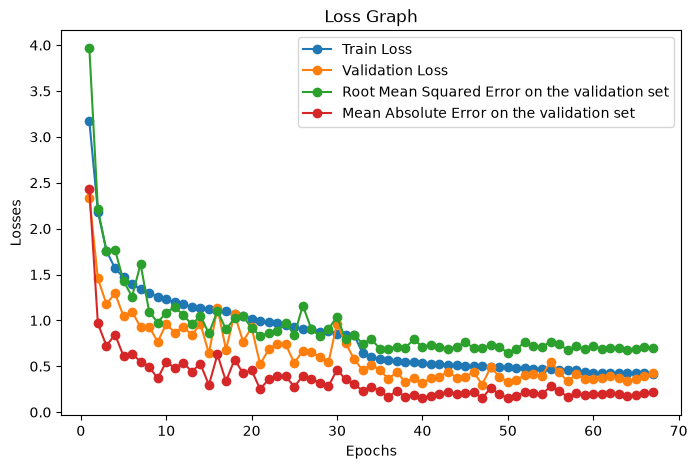

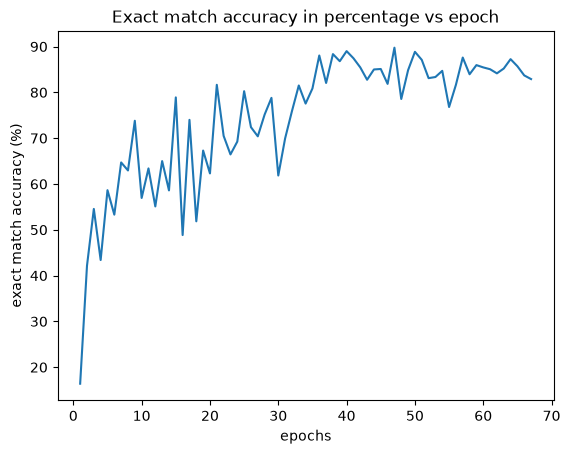

CPU times: total: 27min 4s
Wall time: 26min 21s


TransformerClassifier(
  (embedding): Embedding(16, 128, padding_idx=0)
  (pos_embedding): SinusoidalPositionalEmbedding()
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-2): 3 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=512, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=512, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (fc): Linear(in_features=256, out_features=199, bias=True)
)

In [37]:
%%time

# Instantiate the custom TransformerClassifier model

#MAX_LENGTH = 64
EMBEDDING_DIM = 128
HIDDEN_DIM = 512
NUM_HEADS = 4
NUM_LAYERS = 3
DROPOUT = 0.1


transformer_model = TransformerClassifier(
    vocab_size=VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    num_heads=NUM_HEADS,
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT
)
print(f'Number of Parameters: {sum(p.numel() for p in transformer_model.parameters())}\n')

optimizer = torch.optim.Adam(transformer_model.parameters(), lr=0.001)
loss_fn = nn.CrossEntropyLoss()
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Convert y_train and y_val to 0-indexed class labels for classification
y_train_classification = (y_train  + 99).values.astype(int)
y_val_classification = (y_val + 99).values.astype(int)


best_transformer = train(
    transformer_model,
    x_train_focused,
    y_train_focused_classification,
    optimizer=optimizer,
    loss_fn=loss_fn,
    normalized_coefficient=0.001,
    epochs=300,
    device=device,
    batch_size=128,
    x_val_data=x_val,
    y_val_data=y_val_classification,
    patience=20,
    verbose=True,
    show_loss_graph=True
)


transformer_model.load_state_dict(best_transformer["best_model_state"])
transformer_model.to(device)


#the message at the beginning can be fixed by erasing the collate_fn and apply this kind of padding directly into the forward method of the transformer, it is not necessary

In [38]:
print("Best Transformer checkpoint")
print("Epoch:", best_transformer["best_model_epoch"])
print("Validation accuracy:", best_transformer["best_model_accuracy"])
print("Validation CE loss:", best_transformer["best_model_loss"])
print("Validation RMSE:", best_transformer["best_model_RMSE"])
print("Validation MAE:", best_transformer["best_model_MAE"])

Best Transformer checkpoint
Epoch: 47
Validation accuracy: 89.75
Validation CE loss: 0.2990853190422058
Validation RMSE: 0.6978538632392883
Validation MAE: 0.15399999916553497


In [39]:
# Save the best Transformer checkpoint so that we can reload it later without retraining.
torch.save(
    {
        "model_state_dict": transformer_model.state_dict(),
        "best_transformer": best_transformer,
        "config": {
            "VOCAB_SIZE": VOCAB_SIZE,
            "EMBEDDING_DIM": EMBEDDING_DIM,
            "HIDDEN_DIM": HIDDEN_DIM,
            "NUM_HEADS": NUM_HEADS,
            "NUM_LAYERS": NUM_LAYERS,
            "DROPOUT": DROPOUT,
        }
    },
    "transformer_classifier_focused_meanmax_aggressive_best.pt"
)

print("Checkpoint saved as transformer_classifier_focused_meanmax_aggressive_best.pt")

Checkpoint saved as transformer_classifier_focused_meanmax_aggressive_best.pt


In [40]:
# Prepare target labels for classification.
# Values are in [-99, 99], so we shift them to class indices in [0, 198].
y_val_classification = (data["validation"]["value"] + 99).values.astype(int)

y_test_id_classification = (data["test_id"]["value"] + 99).values.astype(int)
y_test_ood_classification = (data["test_ood"]["value"] + 99).values.astype(int)
y_test_long_classification = (data["test_long"]["value"] + 99).values.astype(int)


def make_loader(expressions, labels, batch_size=128):
    dataset = list(zip(expressions, labels))
    return torch.utils.data.DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        collate_fn=collate_fn
    )


val_loader = make_loader(
    data["validation"]["expression"],
    y_val_classification,
    batch_size=128
)

test_id_loader = make_loader(
    data["test_id"]["expression"],
    y_test_id_classification,
    batch_size=128
)

test_ood_loader = make_loader(
    data["test_ood"]["expression"],
    y_test_ood_classification,
    batch_size=128
)

test_long_loader = make_loader(
    data["test_long"]["expression"],
    y_test_long_classification,
    batch_size=128
)

In [41]:
validation_longish_df = data["validation"][data["validation"]["length"] >= 17].copy()

y_val_longish_classification = (
    validation_longish_df["value"] + 99
).values.astype(int)

val_longish_loader = make_loader(
    validation_longish_df["expression"],
    y_val_longish_classification,
    batch_size=128
)

print("Long-ish validation size:", len(validation_longish_df))

Long-ish validation size: 33


In [42]:
# Evaluate the best Transformer on all required splits.
transformer_model.eval()

def print_split_metrics(split_name, loader, split_len):
    ce_loss, rmse_loss, mae_loss, correct_matches = evaluate(
        transformer_model,
        loader,
        device
    )

    exact_acc = 100 * correct_matches / split_len

    print(f"{split_name}")
    print(f"Exact-match accuracy: {exact_acc:.2f}%")
    print(f"CE loss: {ce_loss.item():.4f}")
    print(f"RMSE: {rmse_loss.item():.4f}")
    print(f"MAE: {mae_loss.item():.4f}")
    print()


print_split_metrics("Validation", val_loader, len(data["validation"]))
print_split_metrics("ID test", test_id_loader, len(data["test_id"]))
print_split_metrics("OOD test", test_ood_loader, len(data["test_ood"]))
print_split_metrics("Long test", test_long_loader, len(data["test_long"]))
print_split_metrics("Validation long-ish", val_longish_loader, len(validation_longish_df))

Validation
Exact-match accuracy: 89.75%
CE loss: 0.2991
RMSE: 0.6979
MAE: 0.1540

ID test
Exact-match accuracy: 90.70%
CE loss: 0.2935
RMSE: 0.6099
MAE: 0.1300

OOD test
Exact-match accuracy: 79.35%
CE loss: 0.6776
RMSE: 1.9051
MAE: 0.5245

Long test
Exact-match accuracy: 49.80%
CE loss: 1.9250
RMSE: 4.9248
MAE: 2.1173

Validation long-ish
Exact-match accuracy: 30.30%
CE loss: 2.3107
RMSE: 4.0000
MAE: 2.2424



#Model's Performances analysis

In [43]:
def run_transformer_predictor(input_df, device, model, batch_size=128):
  if not isinstance(input_df, pd.DataFrame):
      raise TypeError("Input must be a single pandas DataFrame.")

  predictions = []
  exact_match = []

  # Prepare target labels (shifted by +99 for classification)
  y_labels_classification = (input_df["value"] + 99).values.astype(int)
  expressions = input_df["expression"]

  # Create a DataLoader using the existing make_loader function
  loader = make_loader(expressions, y_labels_classification, batch_size=batch_size)

  model.eval() # Set model to evaluation mode
  with torch.no_grad(): # Disable gradient calculations
      for x_batch, y_batch_classification in loader:
          x_batch = x_batch.to(device)
          y_batch_classification = y_batch_classification.to(device)

          mask = (x_batch == token_to_index[PAD_TOKEN])
          y_pred_logits = model(x_batch, mask)
          y_pred_indices = torch.argmax(y_pred_logits, dim=1)

          # Denormalize predictions and true values back to original range [-99, 99]
          real_y_pred = (y_pred_indices - 99).tolist()
          real_y_true = (y_batch_classification - 99).tolist()

          for i in range(len(real_y_pred)):
              predictions.append(real_y_pred[i])
              if real_y_pred[i] == real_y_true[i]:
                  exact_match.append(True)
              else:
                  exact_match.append(False)

  # Create a copy of the input DataFrame and add the new columns
  output_df = input_df.copy()
  output_df['prediction'] = predictions
  output_df['exact_match'] = exact_match
  return output_df

In [44]:
data_df = run_transformer_predictor(test_long_df, DEVICE, transformer_model)

data_df.head()

NameError: name 'test_long_df' is not defined

In [ ]:
def make_histogram_plots(data_df, x_axis):      #all the histograms will be on exact_match
  if not isinstance(data_df, pd.DataFrame):
      raise TypeError("Input must be a single pandas DataFrame.")

  exact_matches_counts = {}
  total_counts = {}

  for value in data_df[x_axis].unique():
      # Count exact matches for the current x_axis value
      exact_matches_count = data_df[(data_df[x_axis] == value) & (data_df['exact_match'] == True)].shape[0]
      exact_matches_counts[value] = exact_matches_count

      # Count total samples for the current x_axis value
      total_samples_count = data_df[data_df[x_axis] == value].shape[0]
      total_counts[value] = total_samples_count

  # Sort keys for consistent plotting order
  sorted_keys = sorted(exact_matches_counts.keys())
  sorted_exact_matches = [exact_matches_counts[k] for k in sorted_keys]

  if sorted_keys:
      # Plot 1: Number of Exact Matches
      plt.figure(figsize=(12, 6))
      plt.bar(sorted_keys, sorted_exact_matches, color="blue")
      plt.title(f"Exact Matches by Expression {x_axis.replace('_', ' ').title()} for Test Long Dataset")
      plt.xlabel(f"Expression {x_axis.replace('_', ' ').title()}")
      plt.ylabel("Number of Exact Matches")
      plt.xticks(range(min(sorted_keys), max(sorted_keys) + 1))
      plt.show()
  else:
      print(f"No exact matches found for any expression {x_axis.replace('_', ' ').title()} to plot number of matches.")

  # Calculate and plot percentage of exact matches
  exact_match_percentages = {}
  for key in sorted_keys:
      if total_counts.get(key, 0) > 0:
          percentage = (exact_matches_counts.get(key, 0) / total_counts[key]) * 100
          exact_match_percentages[key] = percentage
      else:
          exact_match_percentages[key] = 0 # Handle division by zero if no samples for a key

  if exact_match_percentages:
      # Sort percentages by keys for plotting
      sorted_percentages = [exact_match_percentages[k] for k in sorted_keys]

      # Plot 2: Exact Match Accuracy Percentage
      plt.figure(figsize=(12, 6))
      plt.bar(sorted_keys, sorted_percentages, color="lightcoral")
      plt.title(f"Exact Match Accuracy Percentage by Expression {x_axis.replace('_', ' ').title()} for Test Long Dataset")
      plt.xlabel(f"Expression {x_axis.replace('_', ' ').title()}")
      plt.ylabel("Exact Match Accuracy (%)")
      plt.xticks(range(min(sorted_keys), max(sorted_keys) + 1))
      plt.show()
  else:
      print(f"No exact match percentages by expression {x_axis.replace('_', ' ').title()} to plot.")



make_histogram_plots(data_df, 'length')
make_histogram_plots(data_df, 'depth')